### **lingalingeswaran-asr-sinhala-dataset**

## 0. Setup

All external, non-stdlib packages this notebook needs, installed up front so every later
cell can assume they're present rather than failing partway through a long run.

In [1]:
!pip install -q pandas numpy soundfile tqdm matplotlib torch torchaudio


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip


## 1. Load the dataset

The Lingalingeswaran corpus ships as four Parquet shards (all part of a single `train` split — no train/val/test division exists upstream). We read all four and concatenate into one DataFrame.

**Expect:** ~11,357 rows x 2 columns (`audio_path`, `transcription`).

In [2]:
import pandas as pd
from pathlib import Path

base = Path("lingaData/data")
files = sorted(base.glob("train-*-of-*.parquet"))

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(df.shape)
print(f"Loaded from {len(files)} shards")

(11357, 2)
Loaded from 4 shards


### Inspect the raw structure

A quick look at the first rows to confirm what each column actually contains before we trust it.

In [3]:
df.head(5)

,audio_path,transcription
0,{'bytes': b'RIFF$\xbc\x02\x00WAVEfmt \x10\x00\...,මහවැලි ගඟට ගොස් ආපසු එන ගමනේදී
1,{'bytes': b'RIFF\xa4j\x01\x00WAVEfmt \x10\x00\...,උන්වහන්සේ කපාපු
2,{'bytes': b'RIFF$^\x01\x00WAVEfmt \x10\x00\x00...,එය එතනින් අවසන් නොවී
3,{'bytes': b'RIFF\xa4\xaf\x02\x00WAVEfmt \x10\x...,සිතින් අයහපතෙහි හැසිරීම නිසයි.
4,{'bytes': b'RIFF$\x90\x01\x00WAVEfmt \x10\x00\...,එවන් ශ්‍රේෂ්ඨ ජාතියක් බිහි කිරීමට


## 2. Basic inventory

Total utterances, missing transcripts, and (where available) speaker/metadata breakdowns —
the counts that frame everything downstream.

In [4]:
print("Total utterances:", len(df))
print("missing transcripts:", df["transcription"].isnull().sum())


Total utterances: 11357
missing transcripts: 0


### Transcript length distribution

Character counts per transcript. On its own this is a sanity check, but it becomes the numerator
of the chars-per-second ratio further down, our main misalignment detector.

A minimum near zero means empty/stub transcripts; a very large maximum matters because Whisper's
decoder caps at 448 tokens, and Sinhala tokenizes inefficiently under Whisper's BPE.

In [5]:
df["text_len"] = df["transcription"].str.len()
df["text_len"].describe()

count    11357.000000
mean        25.783658
std         10.576727
min          3.000000
25%         18.000000
50%         24.000000
75%         32.000000
max        108.000000
Name: text_len, dtype: float64

## 3. Duration extraction

`sf.info()` reads only the file header — sample rate, frame count, channels — so duration comes
essentially for free without decoding the full waveform.

`get_duration` handles both shapes the audio cell can take (a HuggingFace-style `{'bytes': ...}`
dict, or raw bytes) and returns `None` on failure rather than raising, so one corrupt file cannot
abort the pass over the whole dataset.

In [6]:
import io
import soundfile as sf

def get_duration(audio):
    if audio is None:
        return None
    raw = audio['bytes'] if isinstance(audio, dict) else audio
    if raw is None:
        return None
    try:
        info = sf.info(io.BytesIO(raw))
        return info.duration
    except Exception:
        return None

df["duration_check"] = df["audio_path"].apply(get_duration)

### Duration summary

Whisper's encoder always consumes a fixed 30-second window: shorter audio is zero-padded, and
**anything longer is silently truncated while the full transcript is kept as the label** — a
direct path to hallucination. The number that matters most here is the maximum.

In [7]:
df["duration_check"].describe()

count    11357.000000
mean         4.365713
std          1.654901
min          1.400000
25%          3.300000
50%          4.000000
75%          5.000000
max         28.500000
Name: duration_check, dtype: float64

### Listen to the longest clip

The single most informative clip to audition manually — if anything breaches the 30 s window or
carries a truncated transcript, it will be this one.

In [8]:
from IPython.display import Audio, display

row = df.loc[df["duration_check"].idxmax()]
raw = row["audio_path"]['bytes'] if isinstance(row["audio_path"], dict) else row["audio_path"]

display(Audio(data=raw))
print(row["duration_check"], "sec")
print(row["transcription"])

28.5 sec
උන්ගේ පුත්තු කොළඹ වහගෙනතියනකොට රටේ තවත් පැත්තක ලමි ඉස්කෝලේ යන්නේ වල පාලමක කැඩිච්ච ලනුවක එල්ලිලා.


## **Transcript-audio alignment issues**

### Characters per second

`len(text) / duration` should cluster tightly for genuine speech. Rows outside the band are
almost always broken pairs rather than unusual speakers — too high means more text than the audio
could plausibly contain, too low means a truncated transcript or a mostly-silent/noisy clip.

The 2–30 thresholds are calibrated to Sinhala script; read the printed distribution and cut in the
tails rather than trusting numbers imported from another dataset.

In [9]:
import numpy as np
from IPython.display import Audio, display

df["chars_per_sec"] = df["transcription"].str.len() / df["duration_check"]
print(df["chars_per_sec"].describe())

suspicious = df[(df["chars_per_sec"] > 30) | (df["chars_per_sec"] < 2)]
print(f"Suspicious rows: {len(suspicious)} of {len(df)}")

def play(idx):
    row = df.loc[idx]
    raw = row['audio_path']['bytes'] if isinstance(row['audio_path'], dict) else row['audio_path']
    print(f"[{idx}] {row['duration_check']:.2f}s | {row['chars_per_sec']:.1f} chars/sec")
    print(row['transcription'])
    display(Audio(data=raw))

if len(suspicious):
    play(suspicious["chars_per_sec"].idxmax())

count    11357.000000
mean         6.101403
std          2.008877
min          0.540541
25%          4.680851
50%          6.000000
75%          7.368421
max         14.375000
Name: chars_per_sec, dtype: float64
Suspicious rows: 134 of 11357
[971] 8.60s | 2.0 chars/sec
ඔබට අවංක වීර්යයක්


## **Empty or garbage transcripts**

### Empty and stub transcripts

An empty transcript paired with real speech is the worst training example possible — it teaches
the model that speech maps to nothing. Stub transcripts under a few characters are the milder
version and worth auditioning before deciding fix vs. drop.

In [10]:
text = df["transcription"].fillna("").str.strip()

empty_text = df[text == ""]
very_short_text = df[(text != "") & (text.str.len() < 3)]

print(f"Empty/whitespace: {len(empty_text)}")
print(f"Very short (<3 chars): {len(very_short_text)}")

Empty/whitespace: 0
Very short (<3 chars): 0


## **Duplicates**

### Duplicate transcripts

Duplicates over-weight whatever they contain within a split, and — far worse — leak the answer
if the same transcript appears in both train and test.

In [11]:
text = df["transcription"].fillna("").str.strip()

dup_mask = text.duplicated(keep=False) & (text != "")
print(f"Rows with a duplicated transcript: {dup_mask.sum()}")

dup_groups = df[dup_mask].groupby(text[dup_mask]).groups
print(f"Distinct duplicated transcripts: {len(dup_groups)}")

for t, idxs in list(dup_groups.items())[:3]:
    print(f"\n--- {t[:120]}")
    print(df.loc[idxs, ["duration_check", "chars_per_sec"]].to_string())

Rows with a duplicated transcript: 916
Distinct duplicated transcripts: 451

--- "ආරක්ෂා කිරීමේ" මානසිකවය මිසක්
      duration_check  chars_per_sec
3816             3.8       7.894737
7182             4.8       6.250000

--- adobe photoshop lightroom
      duration_check  chars_per_sec
1302             8.6       2.906977
1619             4.8       5.208333

--- bbc sinhala
      duration_check  chars_per_sec
2330             8.5       1.294118
3059             3.7       2.972973


In [ ]:
from IPython.display import Audio, display

def get_bytes(cell):
    if isinstance(cell, dict):
        return cell["bytes"]
    if isinstance(cell, (bytes, bytearray, np.ndarray)):
        return bytes(cell)
    raise TypeError(type(cell))

N_GROUPS = 5  # how many duplicate-transcript groups to audition

for t, idxs in list(dup_groups.items())[:N_GROUPS]:
    print(f"\n=== Transcript: {t}")
    print(f"File indices sharing this transcript: {list(idxs)}\n")
    for idx in idxs:
        row = df.loc[idx]
        print(f"[{idx}] {row['duration_check']:.2f}s | {row['chars_per_sec']:.1f} chars/sec")
        display(Audio(data=get_bytes(row["audio_path"])))

## **Non-target-language contamination**

### Language contamination

Fraction of each transcript's non-whitespace characters that fall inside the Sinhala Unicode
block (U+0D80–U+0DFF). Some Latin script (code-switching) is expected and fine; `sinhala_ratio == 0`
is the degenerate case worth flagging — a wrong-language row or placeholder rather than real
code-switching.

In [12]:
import re

SINHALA = re.compile(r'[\u0D80-\u0DFF]')
text = df["transcription"].fillna("")

df["sinhala_ratio"] = text.apply(
    lambda t: len(SINHALA.findall(t)) / max(len(re.sub(r'\s', '', t)), 1)
)

no_sinhala = df[df["sinhala_ratio"] == 0]
mostly_latin = df[(df["sinhala_ratio"] > 0) & (df["sinhala_ratio"] < 0.3)]

print(f"No Sinhala at all: {len(no_sinhala)}")
print(f"Mostly non-Sinhala (<30%): {len(mostly_latin)}")
print(df.loc[no_sinhala.index, ["duration_check", "transcription"]].head(10).to_string())

No Sinhala at all: 398
Mostly non-Sinhala (<30%): 0
     duration_check                            transcription
5               3.1                              day offices
33              2.9                     magazines of the 90s
36              2.5                                  android
58              4.2            windows xp service pack 3 sp3
87              8.4  full hindi movies with sinhala subtitle
90             10.6                      election department
97              5.5             world trade center sri lanka
112             6.7                                nokla 525
153             3.1                                ethiopian
167             3.6                      harappa civiliation


## 4. Audio header probe

A second pass over the audio, recording sample rate, channel count, subtype, container format,
and byte size. Errors are captured per-row into an `error` column instead of raised, so one
corrupt file doesn't abort the whole pass.

In [13]:
from tqdm.auto import tqdm

def get_bytes(cell):
    if isinstance(cell, dict):
        return cell["bytes"]
    if isinstance(cell, (bytes, bytearray, np.ndarray)):
        return bytes(cell)
    raise TypeError(type(cell))

rows = []
for i, cell in tqdm(df["audio_path"].items(), total=len(df), desc="headers"):
    r = {"idx": i, "error": None}
    try:
        b = get_bytes(cell)
        r["n_bytes"] = len(b)
        info = sf.info(io.BytesIO(b))
        r.update(sr=info.samplerate, channels=info.channels, subtype=info.subtype,
                 fmt=info.format, frames=info.frames,
                 duration=info.frames / info.samplerate)
    except Exception as e:
        r["error"] = f"{type(e).__name__}: {e}"
    rows.append(r)

meta = pd.DataFrame(rows).set_index("idx")
meta = df[["transcription"]].join(meta)
print("unreadable:", meta.error.notna().sum())
display(meta[meta.error.notna()].head())
meta.head()

/home/yohan-jayasinghe/Documents/GIt_Repos/WhisperSL/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
headers: 100%|██████████| 11357/11357 [00:01<00:00, 8020.75it/s]


unreadable: 0


,transcription,error,n_bytes,sr,channels,subtype,fmt,frames,duration


,transcription,error,n_bytes,sr,channels,subtype,fmt,frames,duration
0,මහවැලි ගඟට ගොස් ආපසු එන ගමනේදී,None,179244,16000,1,PCM_16,WAV,89600,5.6
1,උන්වහන්සේ කපාපු,None,92844,16000,1,PCM_16,WAV,46400,2.9
2,එය එතනින් අවසන් නොවී,None,89644,16000,1,PCM_16,WAV,44800,2.8
3,සිතින් අයහපතෙහි හැසිරීම නිසයි.,None,176044,16000,1,PCM_16,WAV,88000,5.5
4,එවන් ශ්‍රේෂ්ඨ ජාතියක් බිහි කිරීමට,None,102444,16000,1,PCM_16,WAV,51200,3.2


### Duration statistics

Total hours is the number that should shape the training recipe. The `over_30s` / `over_29s` /
`under_0.5s` columns are the actionable ones: anything over 30 s would be truncated against a full
transcript, and sub-0.5 s clips are usually fragments.

In [14]:
ok = meta[meta.error.isna()].copy()

overall = pd.Series({
    "n_clips": len(ok),
    "hours":   ok.duration.sum()/3600,
    "min_s":   ok.duration.min(),
    "p50_s":   ok.duration.quantile(.50),
    "p95_s":   ok.duration.quantile(.95),
    "p99_s":   ok.duration.quantile(.99),
    "max_s":   ok.duration.max(),
    "mean_s":  ok.duration.mean(),
}).round(2)
display(overall.to_frame("linga"))
print(f"clips exceeding Whisper's 30 s window: {(ok.duration > 30).sum()}")

,linga
n_clips,11357.00
hours,13.77
min_s,1.40
p50_s,4.00
p95_s,7.40
p99_s,10.30
max_s,28.50
mean_s,4.37


clips exceeding Whisper's 30 s window: 0


### Format compliance

Whisper requires 16 kHz mono. Groups every distinct (sample rate, channels, subtype, format)
combination so any inconsistency shows up immediately. Sample rate below 16 kHz is the critical
row — it is not fixable, since upsampling cannot restore frequency content never captured.

In [15]:
display(ok.groupby(["sr", "channels", "subtype", "fmt"]).size()
          .rename("count").reset_index().sort_values("count", ascending=False))

print("not 16 kHz:", (ok.sr != 16000).sum(), "->", sorted(ok.sr.unique().tolist()))
print("not mono  :", (ok.channels != 1).sum())
print("subtypes  :", ok.subtype.value_counts().to_dict())

low = ok[ok.sr < 16000]
if len(low):
    print(f"\n\u26a0 {len(low)} clips below 16 kHz ({low.duration.sum()/3600:.2f} h) "
          "— band-limited; upsampling cannot recover this")

,sr,channels,subtype,fmt,count
0,16000,1,PCM_16,WAV,11357


not 16 kHz: 0 -> [16000]
not mono  : 0
subtypes  : {'PCM_16': 11357}


## 5. Level and silence analysis

The first pass that actually decodes the waveforms. `frame_rms` slices the signal into
overlapping 1024-sample windows (64 ms at 16 kHz) advancing 512 samples at a time, computing RMS
energy per window so we can locate *where* silence is, not just how loud the clip is overall.

| Metric | Meaning | Why it matters |
|---|---|---|
| `peak_dbfs` | loudest single sample | near 0 dBFS suggests clipping |
| `rms_dbfs` | average energy | overall loudness; big spreads mean inconsistent levels |
| `clip_frac` | fraction of samples at full scale | actual distortion, unrecoverable |
| `silence_frac` | fraction of frames below threshold | mostly-silent clips waste the encoder window |
| `lead_sil_s` | silence before first voiced frame | segmentation started too early |
| `trail_sil_s` | silence after last voiced frame | segmentation ended too late |

`SIL_DBFS = -45` is an *absolute* level, so a quietly recorded clip can register as mostly silent
even with continuous speech — which is exactly why the VAD cross-check in section 6 exists.

In [16]:
SIL_DBFS, FRAME, HOP = -45.0, 1024, 512

def frame_rms(x):
    if len(x) < FRAME:
        return np.array([np.sqrt(np.mean(x**2) + 1e-12)])
    n = 1 + (len(x) - FRAME)//HOP
    idx = np.arange(FRAME)[None, :] + HOP*np.arange(n)[:, None]
    return np.sqrt(np.mean(x[idx]**2, axis=1) + 1e-12)

def analyse(b):
    x, sr = sf.read(io.BytesIO(b), dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    d = len(x)/sr
    voiced = 20*np.log10(frame_rms(x)) > SIL_DBFS
    hop_s = HOP/sr
    if voiced.any():
        lead  = np.argmax(voiced) * hop_s
        trail = max(0.0, d - (len(voiced)-1-np.argmax(voiced[::-1])) * hop_s)
    else:
        lead = trail = d
    to_db = lambda v: 20*np.log10(max(float(v), 1e-10))
    return dict(peak_dbfs=to_db(np.abs(x).max()),
                rms_dbfs=to_db(np.sqrt(np.mean(x**2))),
                clip_frac=float((np.abs(x) >= .999).mean()),
                silence_frac=float((~voiced).mean()),
                lead_sil_s=float(lead), trail_sil_s=float(trail))

recs = []
for i in tqdm(ok.index, desc="levels + silence"):
    try:
        recs.append({"idx": i, **analyse(get_bytes(df.at[i, "audio_path"]))})
    except Exception as e:
        recs.append({"idx": i, "err": str(e)})

lv = pd.DataFrame(recs).set_index("idx").join(ok[["transcription", "duration"]])
lv.head()

levels + silence: 100%|██████████| 11357/11357 [00:23<00:00, 473.58it/s]


,peak_dbfs,rms_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s,transcription,duration
idx,,,,,,,,
0,-12.960828,-32.426537,0.0,0.568966,2.144,0.992,මහවැලි ගඟට ගොස් ආපසු එන ගමනේදී,5.6
1,-2.955173,-20.176189,0.0,0.247191,0.416,0.148,උන්වහන්සේ කපාපු,2.9
2,-24.697431,-42.104435,0.0,0.581395,1.216,0.368,එය එතනින් අවසන් නොවී,2.8
3,-8.189263,-27.910033,0.0,0.064706,0.000,0.092,සිතින් අයහපතෙහි හැසිරීම නිසයි.,5.5
4,-11.567672,-31.510251,0.0,0.555556,1.184,0.608,එවන් ශ්‍රේෂ්ඨ ජාතියක් බිහි කිරීමට,3.2


### Level report and flagging

`near_silent` catches recordings that essentially failed; `very_quiet` catches level outliers that
are still usable; `clipped` catches distortion; `mostly_silence` and the lead/trail flags catch bad
segment boundaries. `n_flags` sums the conditions per clip so the worst offenders sort to the top.

,rms_dbfs,peak_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s
count,11357.00,11357.00,11357.0,11357.00,11357.00,11357.00
mean,-30.07,-11.23,0.0,0.50,1.09,0.81
std,6.74,7.22,0.0,0.17,0.91,0.60
min,-52.55,-34.80,0.0,0.00,0.00,0.06
5%,-41.58,-23.83,0.0,0.12,0.00,0.08
25%,-34.91,-16.70,0.0,0.42,0.67,0.46
50%,-29.73,-10.65,0.0,0.52,0.96,0.76
75%,-24.65,-5.02,0.0,0.62,1.31,1.08
95%,-19.79,-1.44,0.0,0.75,2.59,1.66
max,-15.95,0.00,0.0,1.00,17.60,21.06


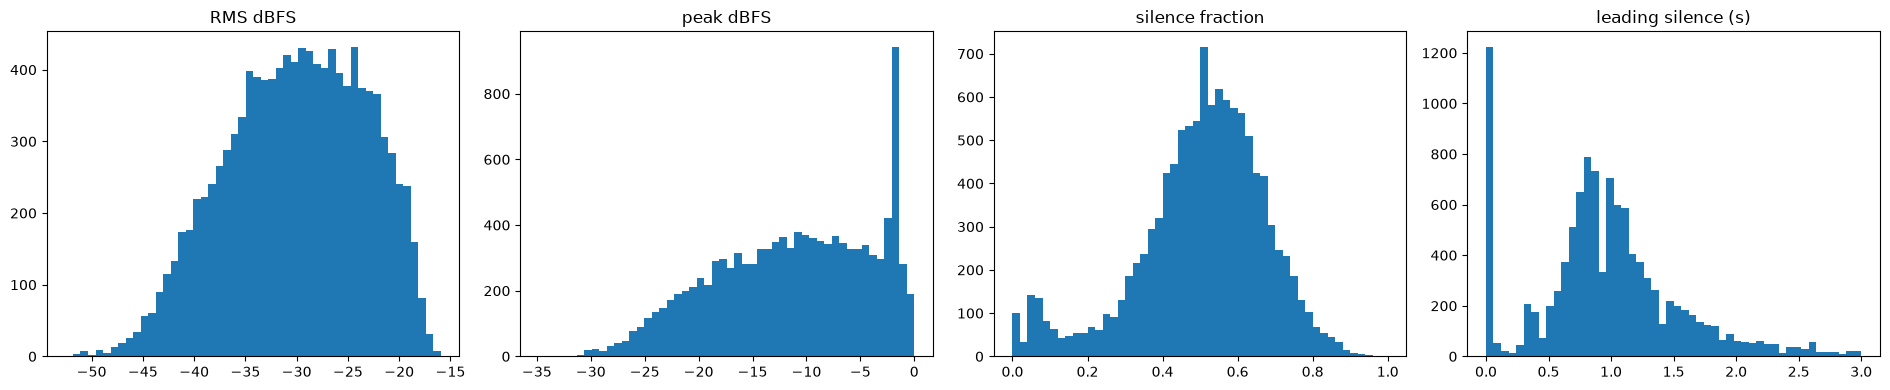

,n_clips
near_silent,11
very_quiet,1571
clipped,0
mostly_silence,3296
long_lead_sil,2112
long_trail_sil,907


,duration,rms_dbfs,clip_frac,silence_frac,lead_sil_s,n_flags
idx,,,,,,
127,5.8,-39.059780,0.0,0.783333,2.304,4
5212,9.1,-46.383247,0.0,0.848057,4.896,4
1813,4.6,-38.581555,0.0,0.739437,1.696,4
5827,10.0,-43.356852,0.0,0.842444,5.568,4
4281,2.5,-50.449081,0.0,1.000000,2.500,4
5112,8.3,-40.042976,0.0,0.848837,5.280,4
7519,5.2,-39.613522,0.0,0.745342,2.336,4
5844,4.5,-39.478957,0.0,0.769784,1.568,4
8481,5.5,-38.013769,0.0,0.676471,2.080,4


In [17]:
import matplotlib.pyplot as plt

cols = ["rms_dbfs", "peak_dbfs", "clip_frac", "silence_frac", "lead_sil_s", "trail_sil_s"]
display(lv[cols].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
ax[0].hist(lv.rms_dbfs.dropna(), bins=50);              ax[0].set_title("RMS dBFS")
ax[1].hist(lv.peak_dbfs.dropna(), bins=50);             ax[1].set_title("peak dBFS")
ax[2].hist(lv.silence_frac.dropna(), bins=50);          ax[2].set_title("silence fraction")
ax[3].hist(lv.lead_sil_s.dropna(), bins=50, range=(0,3)); ax[3].set_title("leading silence (s)")
plt.tight_layout(); plt.show()

flags = pd.DataFrame({
    "near_silent":    lv.rms_dbfs < -50,
    "very_quiet":     lv.rms_dbfs.between(-50, -38),
    "clipped":        lv.clip_frac > .001,
    "mostly_silence": lv.silence_frac > .60,
    "long_lead_sil":  lv.lead_sil_s > 1.5,
    "long_trail_sil": lv.trail_sil_s > 1.5,
})
display(flags.sum().to_frame("n_clips"))

lv["n_flags"] = flags.sum(axis=1)
display(lv.sort_values("n_flags", ascending=False)
          .head(15)[["duration", "rms_dbfs", "clip_frac",
                     "silence_frac", "lead_sil_s", "n_flags"]])

### Audition the worst offenders

The flags detect *signal* problems; the ear detects *label* problems, which hurt WER more. Play
the six highest-`n_flags` clips with their transcripts printed alongside.

In [18]:
from IPython.display import Audio as PlayAudio, display as disp

def play(i):
    x, sr = sf.read(io.BytesIO(get_bytes(df.at[i, "audio_path"])), dtype="float32", always_2d=True)
    print(f"[{i}] {sr} Hz | {len(x)/sr:.2f}s")
    print(df.at[i, "transcription"][:300])
    disp(PlayAudio(x.mean(axis=1), rate=sr))

for i in lv.sort_values("n_flags", ascending=False).index[:6]:
    play(i)
    print("-" * 80)

[127] 16000 Hz | 5.80s
අපිව මුලා කරලා නෑ.


--------------------------------------------------------------------------------
[5212] 16000 Hz | 9.10s
හසන්ත තැන්ක්ස් වේවා හසන්ත


--------------------------------------------------------------------------------
[1813] 16000 Hz | 4.60s
කියල වඩක් නෑ සහෝ.


--------------------------------------------------------------------------------
[5827] 16000 Hz | 10.00s
මෙවැනි වජ්ජ බහුල පුද්ගලයන්


--------------------------------------------------------------------------------
[4281] 16000 Hz | 2.50s
මෙයින් ටික කලකට පසු


--------------------------------------------------------------------------------
[5112] 16000 Hz | 8.30s
එකක් මගේ ෆෝන් එකෙන්


--------------------------------------------------------------------------------


---

# 6. Cross-checking silence with VAD

The energy pass above decides "silence" from a single absolute threshold (`-45 dBFS`), which
measures **loudness**, not **speech** — a quiet but intelligible clip can register as mostly
silent, and steady background noise can register as voiced.

We use **Silero VAD**, a small neural detector (via `torch.hub`) that decides speech from learned
spectral structure rather than raw level, so it fails in genuinely different ways. Agreement between
the two methods means the measurement can be trusted; disagreement gives a shortlist of clips worth
listening to.

### 6.1 VAD-based silence measurement

Silero VAD returns speech **timestamps** directly, so there is no manual framing or smoothing
step. From the timestamps we derive the same quantities as the energy pass, plus segment count.

In [19]:
import torch
import torchaudio

# torch.hub's fork-validation call to the GitHub API can get rate-limited when unauthenticated
# and crash on a missing header; skip that check.
import torch.hub
torch.hub._validate_not_a_forked_repo = lambda a, b, c: True

silero_model, silero_utils = torch.hub.load(
    "snakers4/silero-vad", "silero_vad", trust_repo=True
)
get_speech_timestamps = silero_utils[0]


def vad_analyse(b):
    x, sr = sf.read(io.BytesIO(b), dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    dur = len(x) / sr

    wav = torch.from_numpy(x)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    ts = get_speech_timestamps(wav, silero_model, sampling_rate=16000, return_seconds=True)

    if not ts:
        return dict(vad_silence_frac=1.0, vad_lead_sil_s=dur,
                    vad_trail_sil_s=dur, vad_speech_s=0.0, vad_n_segments=0)

    speech_s = sum(t["end"] - t["start"] for t in ts)

    return dict(
        vad_silence_frac = max(0.0, 1 - speech_s / dur),
        vad_lead_sil_s   = ts[0]["start"],
        vad_trail_sil_s  = max(0.0, dur - ts[-1]["end"]),
        vad_speech_s     = speech_s,
        vad_n_segments   = len(ts),
    )


vrecs = []
for i in tqdm(ok.index, desc="VAD"):
    try:
        vrecs.append({"idx": i, **vad_analyse(get_bytes(df.at[i, "audio_path"]))})
    except Exception as e:
        vrecs.append({"idx": i, "vad_err": str(e)})

vad_df = pd.DataFrame(vrecs).set_index("idx")
print("VAD failures:", vad_df.get("vad_err", pd.Series(dtype=object)).notna().sum())
vad_df.head()

Using cache found in /home/yohan-jayasinghe/.cache/torch/hub/snakers4_silero-vad_master
VAD: 100%|██████████| 11357/11357 [10:40<00:00, 17.72it/s]


VAD failures: 0


,vad_silence_frac,vad_lead_sil_s,vad_trail_sil_s,vad_speech_s,vad_n_segments
idx,,,,,
0,0.535714,2.2,0.8,2.6,1
1,0.517241,0.8,0.7,1.4,1
2,0.428571,1.2,0.0,1.6,1
3,0.472727,1.4,1.2,2.9,1
4,0.500000,1.2,0.4,1.6,1


### 6.2 Compare the two methods

Joining the VAD results onto `lv` and computing the per-clip difference between the two
estimates. Correlation near 1.0 means the methods agree; a consistent bias means the `-45 dBFS`
threshold is mis-set for this corpus; high spread with low bias means individual clips genuinely
need auditioning.

In [20]:
cmp = lv.join(vad_df)

cmp["d_silence"] = cmp.vad_silence_frac - cmp.silence_frac
cmp["d_lead"]    = cmp.vad_lead_sil_s   - cmp.lead_sil_s
cmp["d_trail"]   = cmp.vad_trail_sil_s  - cmp.trail_sil_s

pairs = [("silence_frac", "vad_silence_frac"),
         ("lead_sil_s",   "vad_lead_sil_s"),
         ("trail_sil_s",  "vad_trail_sil_s")]

print("energy vs VAD\n" + "-"*58)
for e, v in pairs:
    s = cmp[[e, v]].dropna()
    print(f"{e:>14} | r={s[e].corr(s[v]):+.3f}  "
          f"mean {s[e].mean():6.3f} -> {s[v].mean():6.3f}  "
          f"bias {(s[v]-s[e]).mean():+.3f}  |diff| p95 {(s[v]-s[e]).abs().quantile(.95):.3f}")

display(cmp[["silence_frac", "vad_silence_frac", "d_silence",
             "lead_sil_s", "vad_lead_sil_s", "d_lead",
             "trail_sil_s", "vad_trail_sil_s", "d_trail"]]
        .describe(percentiles=[.05, .5, .95]).round(3))

energy vs VAD
----------------------------------------------------------
  silence_frac | r=+0.622  mean  0.504 ->  0.495  bias -0.009  |diff| p95 0.315
    lead_sil_s | r=+0.753  mean  1.091 ->  1.355  bias +0.264  |diff| p95 1.400
   trail_sil_s | r=+0.760  mean  0.809 ->  0.797  bias -0.012  |diff| p95 0.824


,silence_frac,vad_silence_frac,d_silence,lead_sil_s,vad_lead_sil_s,d_lead,trail_sil_s,vad_trail_sil_s,d_trail
count,11357.000,11357.000,11357.000,11357.000,11357.000,11357.000,11357.000,11357.000,11357.000
mean,0.504,0.495,-0.009,1.091,1.355,0.264,0.809,0.797,-0.012
std,0.171,0.127,0.135,0.910,0.957,0.657,0.598,0.588,0.411
min,0.000,0.122,-0.501,0.000,0.000,-0.600,0.064,0.000,-2.400
5%,0.124,0.297,-0.147,0.000,0.600,-0.036,0.080,0.100,-0.284
50%,0.522,0.489,-0.036,0.960,1.100,0.032,0.764,0.700,-0.156
95%,0.748,0.714,0.307,2.592,3.000,1.400,1.665,1.600,0.820
max,1.000,1.000,0.862,17.600,19.800,15.288,21.064,20.900,7.092


### 6.3 Visualise the agreement

Points tight on the diagonal mean agreement; a cloud above means VAD finds more silence than
energy (noise counted as speech); a cloud below means VAD finds less (quiet speech counted as
silence).

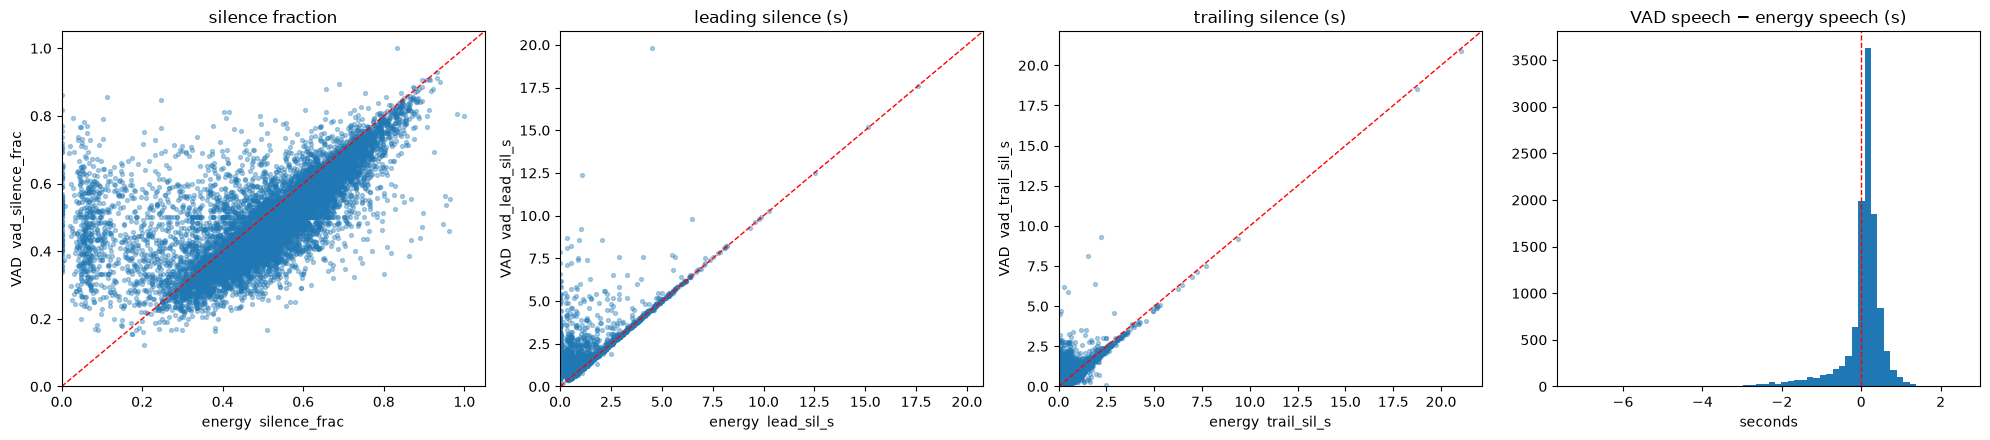

In [21]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

for a, (e, v, t) in zip(ax, [
    ("silence_frac", "vad_silence_frac", "silence fraction"),
    ("lead_sil_s",   "vad_lead_sil_s",   "leading silence (s)"),
    ("trail_sil_s",  "vad_trail_sil_s",  "trailing silence (s)"),
]):
    s = cmp[[e, v]].dropna()
    a.scatter(s[e], s[v], s=8, alpha=.35)
    lim = max(s[e].max(), s[v].max()) * 1.05
    a.plot([0, lim], [0, lim], "r--", lw=1)
    a.set_xlim(0, lim); a.set_ylim(0, lim)
    a.set_xlabel(f"energy  {e}"); a.set_ylabel(f"VAD  {v}"); a.set_title(t)

energy_speech = cmp.duration * (1 - cmp.silence_frac)
ax[3].hist((cmp.vad_speech_s - energy_speech).dropna(), bins=60)
ax[3].axvline(0, color="r", ls="--", lw=1)
ax[3].set_title("VAD speech − energy speech (s)")
ax[3].set_xlabel("seconds")

plt.tight_layout(); plt.show()

### 6.4 Disagreement flags and audition

| Flag | Condition | Interpretation |
|---|---|---|
| `energy_missed_noise` | VAD says silent, energy said voiced | Background noise above threshold |
| `energy_over_trimmed` | VAD says voiced, energy said silent | Quiet speech below threshold |
| `vad_no_speech` | VAD finds no speech at all | Strong candidate for an empty/noise-only clip |
| `very_fragmented` | many separate speech segments | Long internal pauses or merged utterances |
| `vad_speech_too_short` | under 1 s of speech total | Too little content for a 30 s encoder window |

**Listen to these before changing any threshold** — the numbers tell you the two methods
disagree, but only the audio tells you which one is right.

In [22]:
vflags = pd.DataFrame({
    "energy_missed_noise":  (cmp.d_silence >  0.15),
    "energy_over_trimmed":  (cmp.d_silence < -0.15),
    "lead_disagree_0.5s":   (cmp.d_lead.abs()  > 0.5),
    "trail_disagree_0.5s":  (cmp.d_trail.abs() > 0.5),
    "vad_no_speech":        (cmp.vad_speech_s == 0),
    "vad_speech_too_short": (cmp.vad_speech_s < 1.0),
    "very_fragmented":      (cmp.vad_n_segments > 8),
})
display(vflags.sum().to_frame("n_clips"))

cmp["disagreement"] = (cmp.d_silence.abs() + cmp.d_lead.abs()/10 + cmp.d_trail.abs()/10)

print("\nMost contested clips — listen before trusting either method:")
display(cmp.sort_values("disagreement", ascending=False)
           .head(15)[["duration", "rms_dbfs",
                      "silence_frac", "vad_silence_frac", "d_silence",
                      "lead_sil_s", "vad_lead_sil_s",
                      "vad_n_segments", "disagreement"]].round(3))

,n_clips
energy_missed_noise,1059
energy_over_trimmed,531
lead_disagree_0.5s,2010
trail_disagree_0.5s,1288
vad_no_speech,1
vad_speech_too_short,431
very_fragmented,0



Most contested clips — listen before trusting either method:


,duration,rms_dbfs,silence_frac,vad_silence_frac,d_silence,lead_sil_s,vad_lead_sil_s,vad_n_segments,disagreement
idx,,,,,,,,,
2672,28.5,-28.451,0.673,0.726,0.054,4.512,19.8,2,1.588
7843,10.4,-24.887,0.022,0.712,0.690,0.000,6.6,1,1.424
11048,19.3,-22.265,0.684,0.762,0.077,1.056,12.4,1,1.380
5123,10.3,-26.471,0.019,0.689,0.671,0.000,5.3,1,1.371
6720,7.8,-23.879,0.029,0.795,0.766,0.000,1.2,2,1.327
6137,12.2,-28.113,0.279,0.713,0.434,0.000,7.9,1,1.297
6998,6.9,-22.191,0.047,0.768,0.721,0.000,3.5,1,1.243
3388,7.7,-21.659,0.042,0.727,0.685,0.032,5.0,1,1.234
9338,8.9,-30.814,0.206,0.753,0.547,0.032,5.8,1,1.207


In [23]:
for i in cmp.sort_values("disagreement", ascending=False).index[:6]:
    r = cmp.loc[i]
    print(f"[{i}] {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS")
    print(f"    energy: silence {r.silence_frac:.2f}  lead {r.lead_sil_s:.2f}s  trail {r.trail_sil_s:.2f}s")
    print(f"    VAD   : silence {r.vad_silence_frac:.2f}  lead {r.vad_lead_sil_s:.2f}s  "
          f"trail {r.vad_trail_sil_s:.2f}s  segments {int(r.vad_n_segments)}")
    play(i)
    print("-" * 80)

[2672] 28.50s | RMS -28.5 dBFS
    energy: silence 0.67  lead 4.51s  trail 0.85s
    VAD   : silence 0.73  lead 19.80s  trail 0.80s  segments 2
[2672] 16000 Hz | 28.50s
උන්ගේ පුත්තු කොළඹ වහගෙනතියනකොට රටේ තවත් පැත්තක ලමි ඉස්කෝලේ යන්නේ වල පාලමක කැඩිච්ච ලනුවක එල්ලිලා.


--------------------------------------------------------------------------------
[7843] 10.40s | RMS -24.9 dBFS
    energy: silence 0.02  lead 0.00s  trail 0.06s
    VAD   : silence 0.71  lead 6.60s  trail 0.80s  segments 1
[7843] 16000 Hz | 10.40s
විද්‍යාවට ප්‍රඥාව හීනවීම නිසාවෙනි.


--------------------------------------------------------------------------------
[11048] 19.30s | RMS -22.3 dBFS
    energy: silence 0.68  lead 1.06s  trail 0.61s
    VAD   : silence 0.76  lead 12.40s  trail 2.30s  segments 1
[11048] 16000 Hz | 19.30s
හැබැයි සේවා සපයන ආයතනයකට ඇමතුමක් ගත්තට පස්සේ


--------------------------------------------------------------------------------
[5123] 10.30s | RMS -26.5 dBFS
    energy: silence 0.02  lead 0.00s  trail 0.09s
    VAD   : silence 0.69  lead 5.30s  trail 1.80s  segments 1
[5123] 16000 Hz | 10.30s
love sms zone image sinhala nisadas


--------------------------------------------------------------------------------
[6720] 7.80s | RMS -23.9 dBFS
    energy: silence 0.03  lead 0.00s  trail 0.09s
    VAD   : silence 0.79  lead 1.20s  trail 4.50s  segments 2
[6720] 16000 Hz | 7.80s
එතනට රයන් ආවත්


--------------------------------------------------------------------------------
[6137] 12.20s | RMS -28.1 dBFS
    energy: silence 0.28  lead 0.00s  trail 0.07s
    VAD   : silence 0.71  lead 7.90s  trail 0.80s  segments 1
[6137] 16000 Hz | 12.20s
හීලෑ අලි පරපුරට අලූතෙන් ඇතුළත් නොවීම


--------------------------------------------------------------------------------


In [ ]:
# Clips Silero VAD found no speech in at all (vad_no_speech), or under 1s of speech
# (vad_speech_too_short) — listen to confirm they're genuinely silent/noise rather than
# missed quiet speech.
silent_clips = cmp[vflags["vad_no_speech"] | vflags["vad_speech_too_short"]]
print(f"VAD-silent clips: {len(silent_clips)}")

for i in silent_clips.index:
    r = cmp.loc[i]
    print(f"[{i}] {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS | "
          f"vad_speech_s={r.vad_speech_s:.2f}s | energy silence_frac={r.silence_frac:.2f}")
    print(df.at[i, "transcription"][:300])
    play(i)
    print("-" * 80)

In [ ]:
# Clips VAD labeled as exactly 0 speech (vad_speech_s == 0) — the strictest bucket,
# distinct from the broader vad_speech_too_short (<1s) check above.
zero_speech = cmp[cmp["vad_speech_s"] == 0]
print(f"Zero-speech clips: {len(zero_speech)}")

for i in zero_speech.index:
    r = cmp.loc[i]
    print(f"[{i}] {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS | "
          f"energy silence_frac={r.silence_frac:.2f}")
    print(df.at[i, "transcription"][:300])
    play(i)
    print("-" * 80)

---

## 7. What this tells us, and what comes next

1. **Format** — confirm every clip is 16 kHz mono; if so, no resampling step is needed.
2. **Duration** — check for clips approaching or exceeding the 30 s window; filter or truncate-flag
   those explicitly.
3. **Transcript integrity** — use the chars-per-second, empty-text, duplicate, and language checks
   above as a shortlist to fix or drop. Fix where the audio is intact.
4. **Silence and level** — the energy-versus-VAD comparison decides whether a trimming step is
   needed, and which measurement should drive it.

Before training: verify no transcript exceeds Whisper's 448-token decoder limit after
tokenisation, and evaluate un-fine-tuned `whisper-small` on a held-out slice to get a baseline WER.